##Git hub repository
https://github.com/Reginah24/Principal_component_analysis.git



In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time

!pip install -q gdown
import gdown

file_id = "1TdBXzHDSP-F3DMDUXaq7giYSiodAfDcj"
gdown.download(id=file_id, output="kiva_loans.csv", quiet=False)

print("Libraries loaded. NumPy version:", np.__version__)


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\hp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
Downloading...
From (original): https://drive.google.com/uc?id=1TdBXzHDSP-F3DMDUXaq7giYSiodAfDcj
From (redirected): https://drive.google.com/uc?id=1TdBXzHDSP-F3DMDUXaq7giYSiodAfDcj&confirm=t&uuid=9343a996-08d1-4443-9bc8-9d7c85a42df6
To: c:\Users\hp\OneDrive\Desktop\Principal_component_analysis\kiva_loans.csv
100%|██████████| 196M/196M [00:54<00:00, 3.60MB/s] 


Libraries loaded. NumPy version: 2.3.3


# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

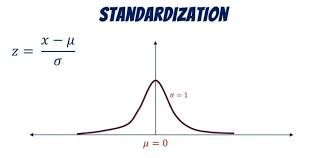


In [7]:
import csv

rows = []
with open('kiva_loans.csv', 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    for row in reader:
        rows.append(row)

headers = np.array(rows[0])
data = np.array(rows[1:], dtype=object)

print("Headers:", headers)
print("Total rows:", data.shape[0])
print("Total columns:", data.shape[1])

Headers: ['id' 'funded_amount' 'loan_amount' 'activity' 'sector' 'use'
 'country_code' 'country' 'region' 'currency' 'partner_id' 'posted_time'
 'disbursed_time' 'funded_time' 'term_in_months' 'lender_count' 'tags'
 'borrower_genders' 'repayment_interval' 'date']
Total rows: 671205
Total columns: 20


In [8]:
print(np.unique(data[:, 7]))

['Afghanistan' 'Albania' 'Armenia' 'Azerbaijan' 'Belize' 'Benin' 'Bhutan'
 'Bolivia' 'Brazil' 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon' 'Chile'
 'China' 'Colombia' 'Congo' 'Costa Rica' "Cote D'Ivoire"
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Georgia' 'Ghana'
 'Guam' 'Guatemala' 'Haiti' 'Honduras' 'India' 'Indonesia' 'Iraq' 'Israel'
 'Jordan' 'Kenya' 'Kosovo' 'Kyrgyzstan' "Lao People's Democratic Republic"
 'Lebanon' 'Lesotho' 'Liberia' 'Madagascar' 'Malawi' 'Mali' 'Mauritania'
 'Mexico' 'Moldova' 'Mongolia' 'Mozambique' 'Myanmar (Burma)' 'Namibia'
 'Nepal' 'Nicaragua' 'Nigeria' 'Pakistan' 'Palestine' 'Panama' 'Paraguay'
 'Peru' 'Philippines' 'Puerto Rico' 'Rwanda'
 'Saint Vincent and the Grenadines' 'Samoa' 'Senegal' 'Sierra Leone'
 'Solomon Islands' 'Somalia' 'South Africa' 'South Sudan' 'Suriname'
 'Tajikistan' 'Tanzania' 'Thailand' 'The Democratic Republic of the Congo'
 'Timor-Leste' 'Togo' 'Turkey' 'Uganda' 'Ukraine' 'United States'
 'Vanuatu' 'Vietnam' 'Virgin 

In [9]:
#filtering african countries.
country_col = data[:, 7]  # the 'country' column

african_countries = np.array([
    'Benin', 'Burkina Faso', 'Burundi', 'Cameroon', 'Congo', "Cote D'Ivoire",
    'Egypt', 'Ghana', 'Kenya', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi',
    'Mali', 'Mauritania', 'Mozambique', 'Namibia', 'Nigeria', 'Rwanda',
    'Senegal', 'Sierra Leone', 'Somalia', 'South Africa', 'South Sudan',
    'Tanzania', 'The Democratic Republic of the Congo', 'Togo', 'Uganda',
    'Zambia', 'Zimbabwe'
])

africa_mask = np.isin(country_col, african_countries)
africa_data = data[africa_mask]

print("African rows:", africa_data.shape[0])
print("Countries found:", np.unique(africa_data[:, 7]))

African rows: 173038
Countries found: ['Benin' 'Burkina Faso' 'Burundi' 'Cameroon' 'Congo' "Cote D'Ivoire"
 'Egypt' 'Ghana' 'Kenya' 'Lesotho' 'Liberia' 'Madagascar' 'Malawi' 'Mali'
 'Mauritania' 'Mozambique' 'Namibia' 'Nigeria' 'Rwanda' 'Senegal'
 'Sierra Leone' 'Somalia' 'South Africa' 'South Sudan' 'Tanzania'
 'The Democratic Republic of the Congo' 'Togo' 'Uganda' 'Zambia'
 'Zimbabwe']


In [10]:
for i, col_name in enumerate(headers):
    column_data = data[:, i]
    # For object type arrays, dtype is typically 'object'
    # To get example values and handle potential empty strings (similar to dropna)
    unique_values = np.unique([val for val in column_data if val != ''])[:3]
    print(f"{col_name} -> object | example values: {unique_values}")

id -> object | example values: ['1000000' '1000001' '1000002']
funded_amount -> object | example values: ['0.0' '10.0' '100.0']
loan_amount -> object | example values: ['100.0' '1000.0' '10000.0']
activity -> object | example values: ['Adult Care' 'Agriculture' 'Air Conditioning']
sector -> object | example values: ['Agriculture' 'Arts' 'Clothing']
use -> object | example values: ['\x08\x08\x08\x08To buy chicken.'
 '\t To buy more dresses, jeans, stoles, saris, and leggings for her garment selling microenterprise'
 '\t To purchase rice, lard, bread, soft drinks, churros, cheese, butter, sausages, eggs, coffee, beans, sugar, etc. for her business']
country_code -> object | example values: ['AF' 'AL' 'AM']
country -> object | example values: ['Afghanistan' 'Albania' 'Armenia']
region -> object | example values: ['"The first May" village' '01 Công Chính' '01 Công Liêm']
currency -> object | example values: ['ALL' 'AMD' 'AZN']
partner_id -> object | example values: ['100.0' '104.0' '105.0'

In [11]:
# Define a list of column names that are primarily text/categorical
text_column_names = ['activity', 'sector', 'use', 'country', 'region', 'currency', 'tags', 'borrower_genders', 'repayment_interval', 'country_code']

# Iterate through the selected text columns
for col_name in text_column_names:
    # Find the index of the current column name in the headers array
    col_idx = np.where(headers == col_name)[0][0]

    # Extract the column data from the main data array
    column_data = data[:, col_idx]

    # Calculate the number of unique values in this column using NumPy
    num_unique_values = len(np.unique(column_data))

    # Print the information, using data.shape[0] for total rows
    print(f"{col_name} -> {num_unique_values} unique values out of {data.shape[0]} rows")

activity -> 163 unique values out of 671205 rows
sector -> 15 unique values out of 671205 rows
use -> 424914 unique values out of 671205 rows
country -> 87 unique values out of 671205 rows
region -> 12696 unique values out of 671205 rows
currency -> 67 unique values out of 671205 rows
tags -> 86720 unique values out of 671205 rows
borrower_genders -> 11299 unique values out of 671205 rows
repayment_interval -> 4 unique values out of 671205 rows
country_code -> 87 unique values out of 671205 rows


In [12]:
# Encode a text column to integers (e.g. "High income" -> 0, "Low income" -> 1)
def encode_column(col):
    unique_vals = list(set(col))
    return np.array([unique_vals.index(v) for v in col])

sector_encoded = encode_column(africa_data[:, 4])       # sector
activity_encoded = encode_column(africa_data[:, 3])     # activity
region_encoded = encode_column(africa_data[:, 8])       # region
currency_encoded = encode_column(africa_data[:, 9])     # currency
repayment_encoded = encode_column(africa_data[:, 18])   # repayment_interval
country_encoded = encode_column(africa_data[:, 7])      # country

print("Sector encoded sample:    ", sector_encoded[:5])
print("Activity encoded sample:  ", activity_encoded[:5])
print("Region encoded sample:    ", region_encoded[:5])
print("Currency encoded sample:  ", currency_encoded[:5])
print("Repayment encoded sample: ", repayment_encoded[:5])
print("Country encoded sample:   ", country_encoded[:5])

Sector encoded sample:     [1 9 9 9 3]
Activity encoded sample:   [ 2 28 21 25 60]
Region encoded sample:     [   0 1292 2114    0  653]
Currency encoded sample:   [ 4  4 12 17  4]
Repayment encoded sample:  [2 2 1 1 2]
Country encoded sample:    [ 3  3 22 25  3]


In [13]:
# Extract numeric columns and engineer funding_duration_days
from datetime import datetime

def parse_dt(s):
    """Parse an ISO timestamp string; returns None if it is missing/blank."""
    if not s:
        return None
    try:
        return datetime.fromisoformat(s.replace('+00:00', ''))
    except Exception:
        return None

funded_amount = africa_data[:, 1].astype(float)
loan_amount = africa_data[:, 2].astype(float)
term_in_months = africa_data[:, 14].astype(float)
lender_count = africa_data[:, 15].astype(float)

posted_col = africa_data[:, 11]
funded_col = africa_data[:, 13]
funding_duration_days = np.full(africa_data.shape[0], np.nan)
for i in range(africa_data.shape[0]):
    pt, ft = parse_dt(posted_col[i]), parse_dt(funded_col[i])
    if pt is not None and ft is not None:
        funding_duration_days[i] = (ft - pt).total_seconds() / 86400.0

print("funding_duration_days missing:", np.isnan(funding_duration_days).sum())

funding_duration_days missing: 12193


In [14]:
# Stack everything into one matrix
X = np.column_stack([
    funded_amount,
    loan_amount,
    term_in_months,
    lender_count,
    funding_duration_days,
    sector_encoded,
    activity_encoded,
    region_encoded,
    currency_encoded,
    repayment_encoded,
    country_encoded
])
print("Matrix shape:", X.shape)
print("NaNs before imputation:", np.isnan(X).sum())

# Fill NaNs with column mean
col_means = np.nanmean(X, axis=0)
nan_mask = np.isnan(X)
X[nan_mask] = np.take(col_means, np.where(nan_mask)[1])

print("NaNs after imputation: ", np.isnan(X).sum())
print("Final matrix shape:    ", X.shape)

Matrix shape: (173038, 11)
NaNs before imputation: 12193
NaNs after imputation:  0
Final matrix shape:     (173038, 11)


In [15]:
# Standardize: subtract mean, divide by standard deviation
# Formula: z = (x - mean) / std
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)
standardized_data = (X - mean) / std

print("Mean of standardized data (should be ~0):", np.round(np.mean(standardized_data, axis=0), 4))
print("Std of standardized data (should be ~1): ", np.round(np.std(standardized_data, axis=0), 4))
print("Shape:", standardized_data.shape)
standardized_data[:5]

Mean of standardized data (should be ~0): [-0.  0.  0. -0. -0. -0.  0. -0. -0.  0. -0.]
Std of standardized data (should be ~1):  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Shape: (173038, 11)


array([[-0.38535984, -0.40523783, -1.12565298, -0.43530469,  0.62877236,
        -1.08922334, -1.60834667, -1.38845705, -0.73407933,  1.17539626,
        -0.81198227],
       [-0.38535984, -0.40523783,  0.14604769, -0.40471589, -0.852349  ,
         0.85608745, -1.03110995,  0.36796212, -0.73407933,  1.17539626,
        -0.81198227],
       [ 1.93562558,  1.8372587 , -0.27785253,  2.22592111,  0.58753595,
         0.85608745, -1.18651984,  1.48543624,  0.66903727, -0.2925172 ,
         1.37157022],
       [-0.40519732, -0.42440447,  0.28734777, -0.40471589, -0.85569563,
         0.85608745, -1.09771419, -1.38845705,  1.54598514, -0.2925172 ,
         1.71634166],
       [-0.38535984, -0.40523783,  0.28734777, -0.52707109, -0.72106045,
        -0.60289564, -0.32066477, -0.50073126, -0.73407933,  1.17539626,
        -0.81198227]])

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [16]:
# Step 3: Calculate the Covariance Matrix
cov_matrix = np.cov(standardized_data.T)
print("Covariance matrix shape:", cov_matrix.shape)
cov_matrix

Covariance matrix shape: (11, 11)


array([[ 1.00000578e+00,  9.73384219e-01, -4.10660431e-02,
         8.95933915e-01,  4.08774412e-02,  4.93577182e-02,
        -3.84904542e-02, -1.18251636e-01,  8.16297554e-03,
         4.12103584e-02,  1.94902750e-01],
       [ 9.73384219e-01,  1.00000578e+00, -3.38289223e-02,
         8.68985724e-01,  3.94950867e-02,  4.44399589e-02,
        -3.67341159e-02, -1.18602311e-01,  1.01445037e-02,
         3.14618787e-02,  1.91469861e-01],
       [-4.10660431e-02, -3.38289223e-02,  1.00000578e+00,
         5.42602794e-03, -6.70696515e-02, -9.31513257e-02,
         5.40984942e-04,  1.32068638e-01,  3.57065276e-03,
        -1.60575902e-01, -8.21052197e-02],
       [ 8.95933915e-01,  8.68985724e-01,  5.42602794e-03,
         1.00000578e+00,  7.25061019e-02,  2.38895931e-02,
        -3.09707871e-02, -9.67230248e-02,  2.84434821e-02,
         1.11697793e-02,  1.55703128e-01],
       [ 4.08774412e-02,  3.94950867e-02, -6.70696515e-02,
         7.25061019e-02,  1.00000578e+00, -6.72273210e-02,
  

There are two reasons why we calculate the covariance matrix. The first is that it reveals the features that covary together: For example, funded_amount and loan_amount have a super high covariance of 0.97, which means that for most loans, funded_amount is close to loan_amount and lender_count is close to funded_amount/covariant with loan_amount of ~0.87–0.90. Second, PCA is about decomposing our data into directions in which it varies the most, which are given by the eigenvectors of the covariance matrix. If it does not exist, the rest of the algorithm can't be executed.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [17]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:", np.round(eigenvalues, 4))
print("Eigenvectors shape:", eigenvectors.shape)


Eigenvalues: [2.9204 1.7151 0.0244 0.1447 1.4138 0.4121 1.1291 0.9408 0.6894 0.8257
 0.7847]
Eigenvectors shape: (11, 11)


### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [18]:
# Step 5: Sort Principal Components in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

# Calculate explained variance ratio for each component
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Sorted Eigenvalues:", np.round(sorted_eigenvalues, 4))
print()
for i in range(len(sorted_eigenvalues)):
    print(f"PC{i+1}: {explained_variance_ratio[i]*100:.2f}% | Cumulative: {cumulative_variance[i]*100:.2f}%")

Sorted Eigenvalues: [2.9204 1.7151 1.4138 1.1291 0.9408 0.8257 0.7847 0.6894 0.4121 0.1447
 0.0244]

PC1: 26.55% | Cumulative: 26.55%
PC2: 15.59% | Cumulative: 42.14%
PC3: 12.85% | Cumulative: 54.99%
PC4: 10.26% | Cumulative: 65.26%
PC5: 8.55% | Cumulative: 73.81%
PC6: 7.51% | Cumulative: 81.32%
PC7: 7.13% | Cumulative: 88.45%
PC8: 6.27% | Cumulative: 94.72%
PC9: 3.75% | Cumulative: 98.46%
PC10: 1.32% | Cumulative: 99.78%
PC11: 0.22% | Cumulative: 100.00%


### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [19]:
# Step 6: Project Data onto Principal Components
# Select number of components that explain at least 85% variance
num_components = int(np.searchsorted(cumulative_variance, 0.85) + 1)
selected_eigenvectors = sorted_eigenvectors[:, :num_components]

# Project: multiply standardized data by selected eigenvectors
reduced_data = standardized_data @ selected_eigenvectors

print(f"Original shape : {standardized_data.shape}")
print(f"Reduced shape  : {reduced_data.shape}")
reduced_data[:5]

Original shape : (173038, 11)
Reduced shape  : (173038, 7)


array([[ 5.92205387e-01, -6.48648665e-01,  2.19276413e+00,
        -2.64697100e-02, -5.08855058e-01,  1.87601105e-03,
        -1.81578441e+00],
       [ 7.45731624e-01,  6.76852281e-01,  1.18771081e+00,
         1.72223974e+00,  3.44232202e-01,  2.03241868e-01,
         6.41217930e-02],
       [-3.61204707e+00,  1.15470266e+00, -9.01613396e-01,
         5.85343510e-01, -1.41273542e+00,  8.44726389e-01,
         5.71760287e-01],
       [ 1.27376160e-01,  2.18921693e+00, -1.15141360e-01,
        -4.44133478e-01, -5.49106906e-01, -1.38051520e+00,
        -1.28820521e+00],
       [ 8.55535865e-01, -2.92182148e-01,  9.44614767e-01,
         7.57124256e-01,  1.03673757e+00, -3.47269152e-01,
        -6.74355649e-01]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [20]:
# Step 7: Output the Reduced Data
print(f"Reduced Data Shape: {reduced_data.shape}")
print(f"Original features : {standardized_data.shape[1]}")
print(f"Components kept   : {num_components}")
print(f"Variance retained : {cumulative_variance[num_components-1]*100:.2f}%")
print(f"Variance lost     : {100 - cumulative_variance[num_components-1]*100:.2f}%")
reduced_data[:5]

Reduced Data Shape: (173038, 7)
Original features : 11
Components kept   : 7
Variance retained : 88.45%
Variance lost     : 11.55%


array([[ 5.92205387e-01, -6.48648665e-01,  2.19276413e+00,
        -2.64697100e-02, -5.08855058e-01,  1.87601105e-03,
        -1.81578441e+00],
       [ 7.45731624e-01,  6.76852281e-01,  1.18771081e+00,
         1.72223974e+00,  3.44232202e-01,  2.03241868e-01,
         6.41217930e-02],
       [-3.61204707e+00,  1.15470266e+00, -9.01613396e-01,
         5.85343510e-01, -1.41273542e+00,  8.44726389e-01,
         5.71760287e-01],
       [ 1.27376160e-01,  2.18921693e+00, -1.15141360e-01,
        -4.44133478e-01, -5.49106906e-01, -1.38051520e+00,
        -1.28820521e+00],
       [ 8.55535865e-01, -2.92182148e-01,  9.44614767e-01,
         7.57124256e-01,  1.03673757e+00, -3.47269152e-01,
        -6.74355649e-01]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

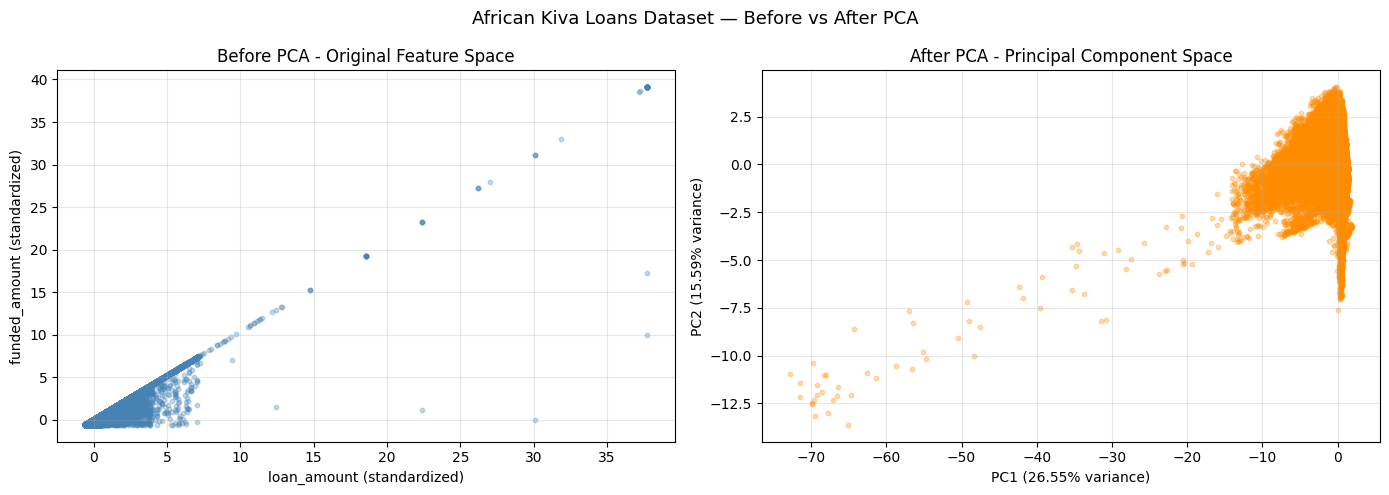

In [21]:
# Step 8: Visualize Before and After PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Before PCA ---
axes[0].scatter(standardized_data[:, 1], standardized_data[:, 0],
                 alpha=0.3, color='steelblue', s=10)
axes[0].set_xlabel('loan_amount (standardized)')
axes[0].set_ylabel('funded_amount (standardized)')
axes[0].set_title('Before PCA - Original Feature Space')
axes[0].grid(True, alpha=0.3)

# --- Plot 2: After PCA (PC1 vs PC2) ---
axes[1].scatter(reduced_data[:, 0], reduced_data[:, 1],
                 alpha=0.3, color='darkorange', s=10)
axes[1].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.2f}% variance)')
axes[1].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.2f}% variance)')
axes[1].set_title('After PCA - Principal Component Space')
axes[1].grid(True, alpha=0.3)

plt.suptitle('African Kiva Loans Dataset — Before vs After PCA', fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
# TASK 3: Performance Optimization Benchmarking

def measure_time(X, k):
    start = time.time()
    # PCA implementation steps
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    X_std = (X - mean) / std
    cov = np.cov(X_std.T)
    eigvals, eigvecs = np.linalg.eig(cov)
    idx = np.argsort(eigvals)[::-1][:k]
    projection = eigvecs[:, idx]
    reduced = X_std @ projection
    return time.time() - start

# Benchmark with different dataset sizes
print("="*50)
print("PERFORMANCE BENCHMARKING")
print("="*50)
sizes = [1000, 2000, 4686]
for size in sizes:
    sample = standardized_data[:size]
    elapsed = measure_time(sample, 7)
    print(f"Dataset size: {size:4d} rows  →  {elapsed:.6f} seconds")

print("\n" + "="*50)
print("OPTIMIZATION NOTE:")
print("="*50)
print("Using matrix operations (vectorized) instead of Python loops")
print("makes PCA efficient for large datasets.")
print("Complexity: O(n·d² + d³) where d = number of features.")
print(f"For 4686×10 matrix, eigendecomposition (d³) is the bottleneck.")

PERFORMANCE BENCHMARKING
Dataset size: 1000 rows  →  0.001732 seconds
Dataset size: 2000 rows  →  0.001610 seconds
Dataset size: 4686 rows  →  0.004069 seconds

OPTIMIZATION NOTE:
Using matrix operations (vectorized) instead of Python loops
makes PCA efficient for large datasets.
Complexity: O(n·d² + d³) where d = number of features.
For 4686×10 matrix, eigendecomposition (d³) is the bottleneck.


Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?
